# Etapa 4 — Regresión Supervisada

**Pregunta:** ¿Cuánto se adjudica en un contrato dado?  
**Target:** `monto_total_adjudicado`

## Objetivo

Construir un modelo capaz de predecir el monto adjudicado de un proceso 
de contratación a partir de sus características observables — tipo de 
procedimiento, categoría, institución convocante, y variables temporales.

## Consideraciones previas

- Los montos están expresados en guaraníes corrientes sin ajuste 
  por inflación — período corto (2021–2022) minimiza el impacto.
- La distribución del target es fuertemente sesgada a la derecha — 
  unos pocos contratos de valor extremo dominan la escala. Se aplicará 
  transformación logarítmica antes del modelado.
- Se usará el mismo dataset de clasificación (`df_model`) para mantener 
  consistencia metodológica entre etapas.

## Métrica principal

**RMSE** (Root Mean Squared Error) en escala logarítmica y **R²** para 
evaluar la capacidad explicativa del modelo. Se reportan ambos en escala 
original para interpretabilidad.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../datos/df_model.csv")

print(df["monto_total_adjudicado"].describe())
print(f"\nSkewness: {df['monto_total_adjudicado'].skew():.2f}")

count            25_018.00
mean     11_581_344_425.62
std      59_491_288_607.83
min             124_950.00
25%          75_000_000.00
50%         175_007_500.00
75%       1_051_608_000.00
max     880_093_200_000.00
Name: monto_total_adjudicado, dtype: float64

Skewness: 9.12


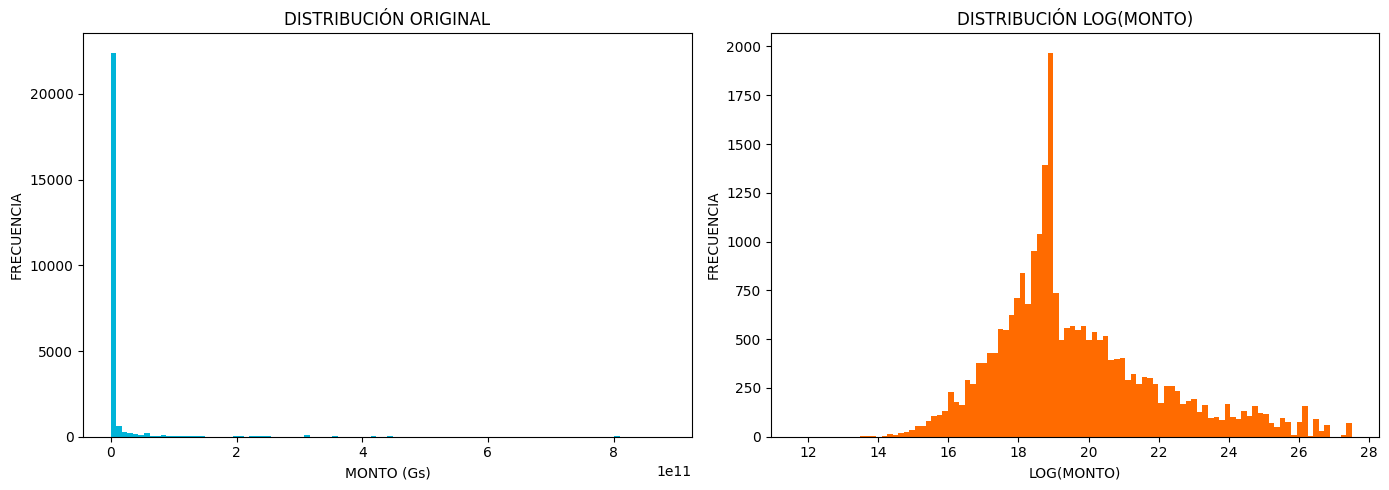

Skewness log: 0.89


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original
axes[0].hist(df["monto_total_adjudicado"], bins=100, 
             color="#00B4D8", edgecolor="none")
axes[0].set_title("DISTRIBUCIÓN ORIGINAL")
axes[0].set_xlabel("MONTO (Gs)")
axes[0].set_ylabel("FRECUENCIA")

# Distribución log
axes[1].hist(np.log1p(df["monto_total_adjudicado"]), bins=100,
             color="#FF6B00", edgecolor="none")
axes[1].set_title("DISTRIBUCIÓN LOG(MONTO)")
axes[1].set_xlabel("LOG(MONTO)")
axes[1].set_ylabel("FRECUENCIA")

plt.tight_layout()
plt.savefig("../figs/fig08_distribucion_monto.png", dpi=150, bbox_inches="tight")
plt.show()

# Crear target transformado
df["log_monto"] = np.log1p(df["monto_total_adjudicado"])
print(f"Skewness log: {df['log_monto'].skew():.2f}")

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

features = [
    "tipo_proc_agrupado",
    "categoria_corta",
    "monto_periodo",
]

X = df[features].copy()
y = df["log_monto"]

# Encodear categóricas
for col in ["tipo_proc_agrupado", "categoria_corta"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (20014, 3) | Test: (5004, 3)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Modelo 1 — Regresión Lineal
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Modelo 2 — Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


for nombre, y_pred in [("Regresión Lineal", y_pred_lr), ("Random Forest", y_pred_rf)]:
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{nombre}")
    print(f"  RMSE (log): {rmse:.4f}")
    print(f"  R²:         {r2:.4f}")
    print()

Regresión Lineal
  RMSE (log): 1.8907
  R²:         0.3409

Random Forest
  RMSE (log): 0.5223
  R²:         0.9497



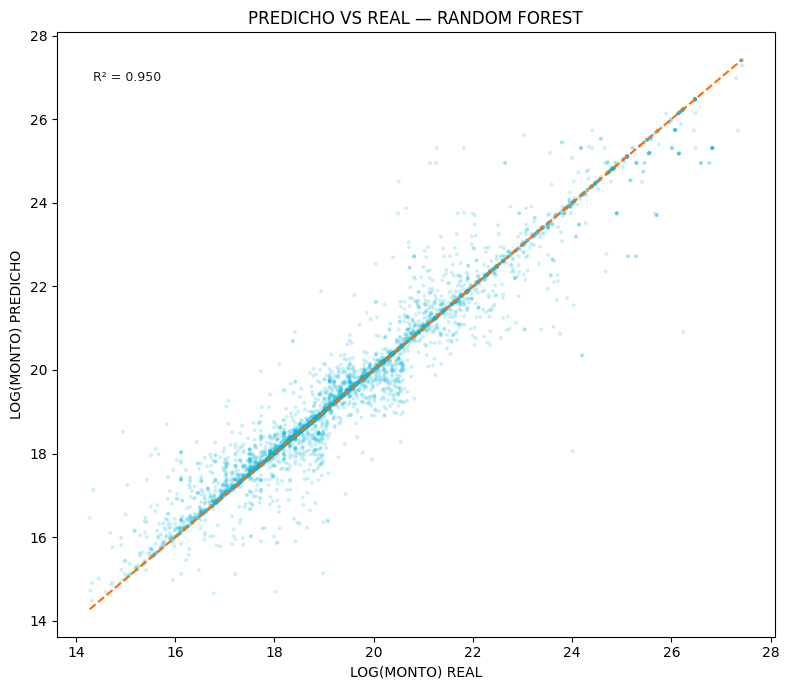

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(y_test, y_pred_rf, alpha=0.2, s=8, color="#00B4D8", edgecolor="none")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="#FF6B00", linewidth=1.5, linestyle="--")

ax.set_title("PREDICHO VS REAL — RANDOM FOREST")
ax.set_xlabel("LOG(MONTO) REAL")
ax.set_ylabel("LOG(MONTO) PREDICHO")
ax.text(0.05, 0.92, f"R² = 0.950", transform=ax.transAxes,
        fontsize=9, color="#1A1A1A")

plt.tight_layout()
plt.savefig("../figs/fig09_predicho_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()

## Regresión supervisada — predicción de monto adjudicado

**Target:** `log(monto_total_adjudicado)` — transformación logarítmica 
aplicada para normalizar una distribución con skewness original de 9.12.

## Comparación de modelos

| Modelo | RMSE (log) | R² |
|---|---|---|
| Regresión Lineal | 1.8907 | 0.3409 |
| Random Forest | 0.5223 | 0.9497 |

La regresión lineal explica apenas el 34% de la varianza — las relaciones 
entre features y monto no son lineales. El Random Forest captura esas 
relaciones no lineales y alcanza un R² de 0.95.

## Gráfico predicho vs real

La línea naranja representa la predicción perfecta (predicho = real). 
Los puntos concentrados sobre la diagonal confirman el alto poder 
predictivo del modelo.

**Lecturas clave:**

- El modelo predice con mayor precisión en el rango central de montos 
  — contratos entre 75M y 1.051M Gs (rango intercuartil del dataset).
- Los extremos presentan mayor dispersión — contratos muy pequeños 
  o muy grandes son más difíciles de predecir con las features disponibles.
- Un R² de 0.95 en escala logarítmica indica que el modelo captura 
  la estructura del dato, pero el error en escala original puede ser 
  considerable dado el rango de valores (124.950 Gs a 880.000M Gs).

> *Nota metodológica: las métricas se reportan en escala logarítmica. 
> El RMSE en escala original sería considerablemente más alto debido 
> a la presencia de contratos de valor extremo.*